In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

DATA_PATH = "/content/drive/MyDrive/mimic_outputs/train_structured_vitals_labs_24h.parquet"
df = pd.read_parquet(DATA_PATH)

print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(61532, 128)


,icustay_id,hadm_id,subject_id,intime,outtime,hospital_expired,icu_age,age_ge_90,gender,insurance,...,bilirubin_total_last,chloride_last,creatinine_last,hemoglobin_last,inr_last,lactate_last,platelets_last,potassium_last,sodium_last,wbc_last
0,280836,110404,268,2198-02-14 23:27:38,2198-02-18 05:26:11,1,65.983559,0,F,Medicare,...,NaN,102.0,2.7,10.0,1.4,1.1,145.0,4.9,131.0,9.7
1,206613,106296,269,2170-11-05 11:05:29,2170-11-08 17:46:57,0,40.099384,0,M,Medicaid,...,NaN,102.0,0.6,11.8,NaN,1.2,240.0,4.3,134.0,9.5
2,220345,188028,270,2128-06-24 15:05:20,2128-06-27 12:32:29,0,80.078300,0,M,Medicare,...,NaN,106.0,1.4,14.9,1.1,NaN,285.0,3.9,140.0,15.3
3,249196,173727,271,2120-08-07 23:12:42,2120-08-10 00:39:04,0,45.684715,0,F,Private,...,0.4,116.0,0.5,7.1,1.3,1.2,290.0,3.6,150.0,13.9
4,210407,164716,272,2186-12-25 21:08:04,2186-12-27 12:01:13,0,67.095146,0,M,Medicare,...,0.6,104.0,1.2,12.0,1.3,NaN,213.0,4.1,140.0,7.8


In [4]:
# Cohort Summary
summary = {
    "n_rows (icustay)": len(df),
    "n_icustay_id": df["icustay_id"].nunique(),
    "n_subject": df["subject_id"].nunique(),
    "n_hadm": df["hadm_id"].nunique(),
    "mortality_rate": float(df["hospital_expired"].mean()),
}
pd.DataFrame([summary])

,n_rows (icustay),n_icustay_id,n_subject,n_hadm,mortality_rate
0,61532,61532,46476,57786,0.107408


In [6]:
# Distribution of ICU stays per patient (motivates patient-level group splitting)
per_subject = df.groupby("subject_id")["icustay_id"].nunique()
per_subject.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

,icustay_id
count,46476.000000
mean,1.323952
std,0.996007
min,1.000000
50%,1.000000
75%,1.000000
90%,2.000000
95%,3.000000
99%,5.000000
max,41.000000


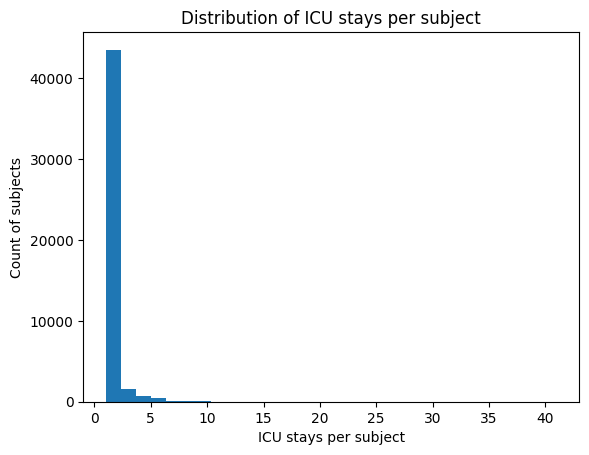

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(per_subject.values, bins=30)
plt.xlabel("ICU stays per subject")
plt.ylabel("Count of subjects")
plt.title("Distribution of ICU stays per subject")
plt.show()

Most patients have only one ICU stay, with a heavily right-skewed distribution and a small long tail of patients experiencing multiple ICU stays (up to ~40).

In [9]:
# Missingness summary (row-level): % of ICU stays with all vitals missing, all labs missing, and both missing
vital_prefixes = ("heart_rate_", "resp_rate_", "spo2_", "map_", "temperature_c_")
lab_prefixes = ("lactate_", "creatinine_", "bun_", "wbc_", "hemoglobin_", "platelets_",
                "sodium_", "potassium_", "chloride_", "bicarbonate_", "bilirubin_total_", "inr_")

vital_cols = [c for c in df.columns if c.startswith(vital_prefixes)]
lab_cols = [c for c in df.columns if c.startswith(lab_prefixes)]

missing_all_vitals = df[vital_cols].isna().all(axis=1).mean()
missing_all_labs = df[lab_cols].isna().all(axis=1).mean()
missing_both = (df[vital_cols].isna().all(axis=1) & df[lab_cols].isna().all(axis=1)).mean()

pd.DataFrame([{
    "fraction_all_vitals_missing": float(missing_all_vitals),
    "fraction_all_labs_missing": float(missing_all_labs),
    "fraction_missing_both": float(missing_both),
}])

,fraction_all_vitals_missing,fraction_all_labs_missing,fraction_missing_both
0,0.03993,0.062764,0.020315


In [10]:
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate.head(15)

,0
bilirubin_total_std,0.918628
lactate_std,0.797731
inr_std,0.681824
bilirubin_total_mean,0.672691
bilirubin_total_max,0.672691
bilirubin_total_min,0.672691
bilirubin_total_last,0.672691
bilirubin_total_count,0.672691
bilirubin_total_median,0.672691
lactate_max,0.637506


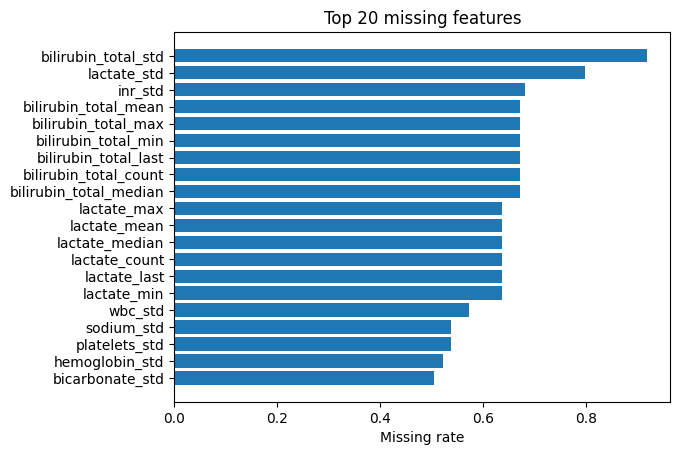

In [11]:
import matplotlib.pyplot as plt

top = missing_rate.head(20)[::-1]
plt.figure()
plt.barh(top.index, top.values)
plt.xlabel("Missing rate")
plt.title("Top 20 missing features")
plt.show()

Most of the highest-missing features come from labs that are not routinely ordered in the first 24 hours (especially bilirubin_total and lactate), so their aggregated statistics (mean/min/max/last/std) naturally show high missing rates. This missingness is clinically plausible and reflects ordering behavior/acuity; models like XGBoost can handle these NaNs directly, and we treat missingness as informative rather than dropping these variables.

In [12]:
# Compare key features between survivors vs. non-survivors (boxplots)
import matplotlib.pyplot as plt

key_candidates = [
    "icu_age",
    "heart_rate_mean", "map_mean", "resp_rate_mean", "spo2_mean", "temperature_c_mean",
    "lactate_max", "lactate_last",
    "creatinine_max", "creatinine_last",
    "bun_max", "wbc_max",
]

keys = [k for k in key_candidates if k in df.columns]
keys

['icu_age',
 'heart_rate_mean',
 'map_mean',
 'resp_rate_mean',
 'spo2_mean',
 'temperature_c_mean',
 'lactate_max',
 'lactate_last',
 'creatinine_max',
 'creatinine_last',
 'wbc_max']

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


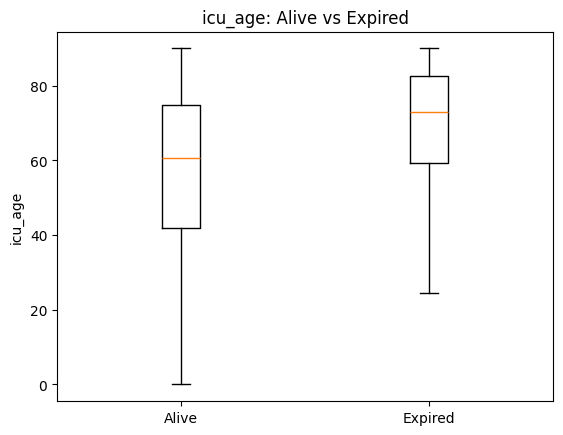

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


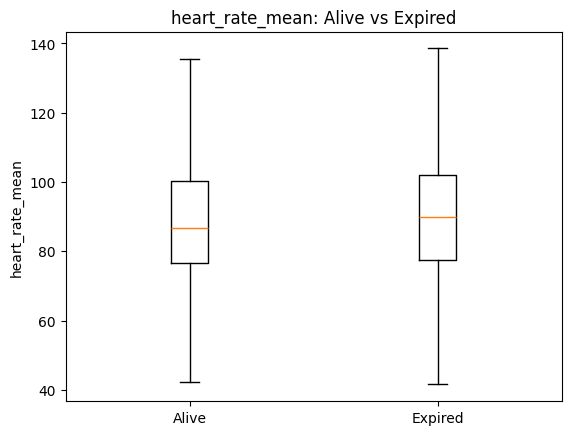

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


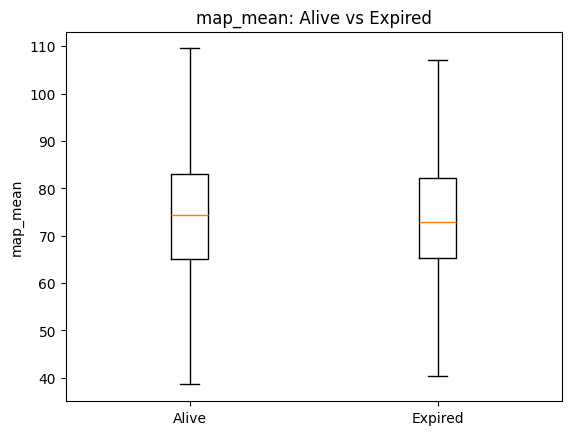

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


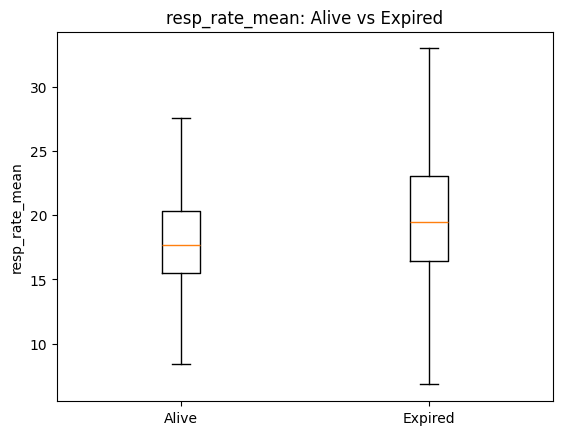

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


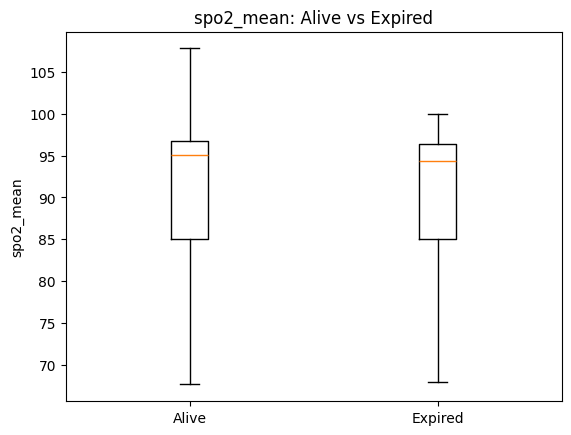

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


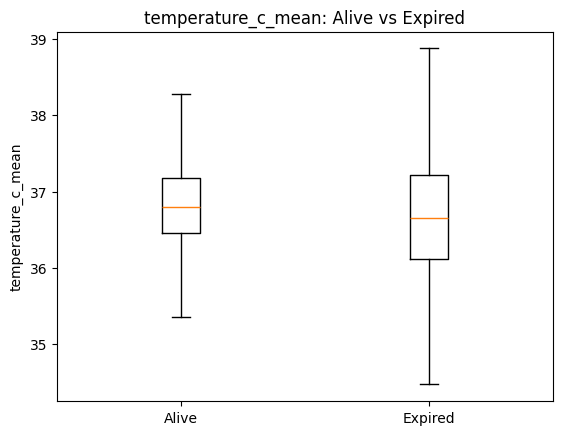

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


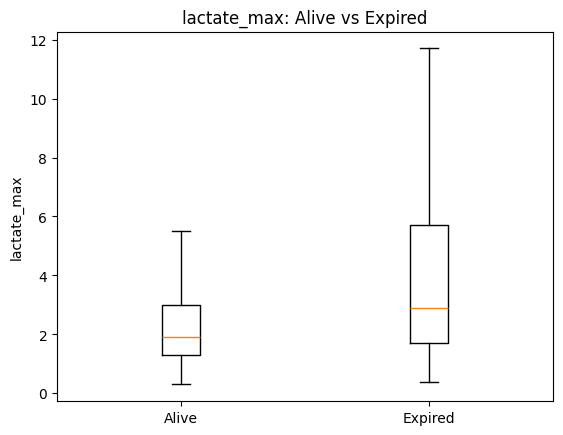

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


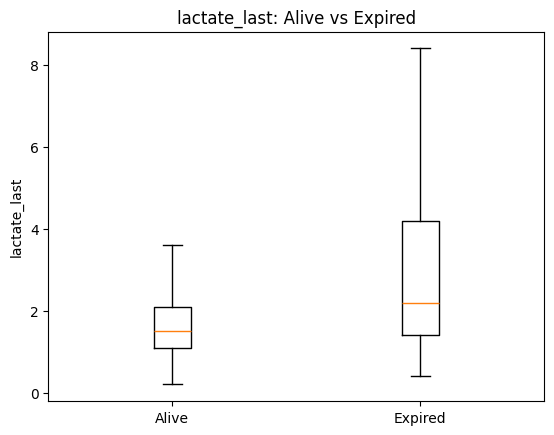

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


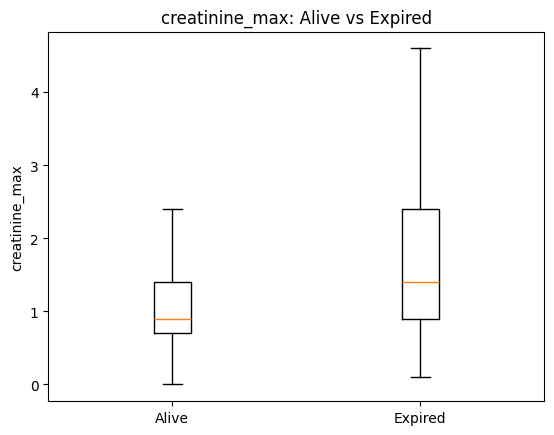

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


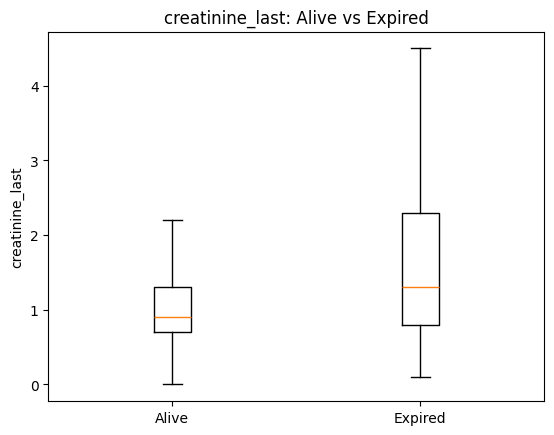

/tmp/ipython-input-551/2301332911.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)


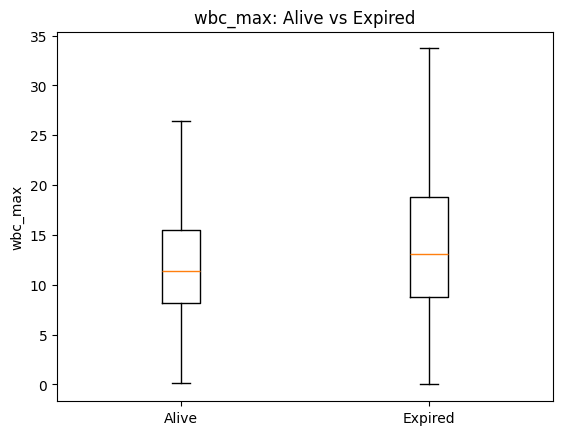

In [13]:
alive = df[df["hospital_expired"] == 0]
dead  = df[df["hospital_expired"] == 1]

for k in keys:
    plt.figure()
    data = [alive[k].dropna().values, dead[k].dropna().values]
    plt.boxplot(data, labels=["Alive", "Expired"], showfliers=False)
    plt.title(f"{k}: Alive vs Expired")
    plt.ylabel(k)
    plt.show()

Non-survivors are substantially **older** and show early signs of **higher physiologic stress**, including a higher mean respiratory rate (and slightly higher mean heart rate). Laboratory markers show clearer separation: **lactate (max/last) **and **creatinine (max/last)** are markedly higher in the expired group, consistent with hypoperfusion/metabolic stress and acute kidney injury being associated with increased mortality risk in the first 24 hours.

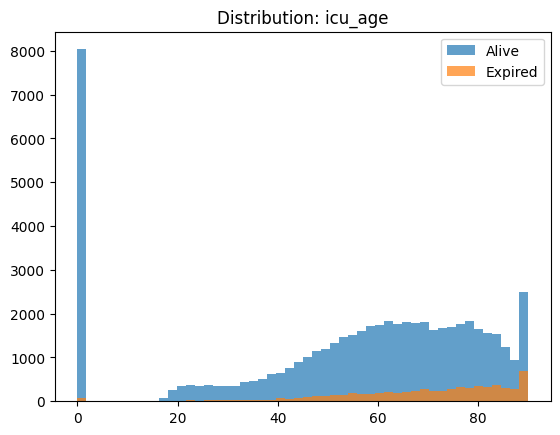

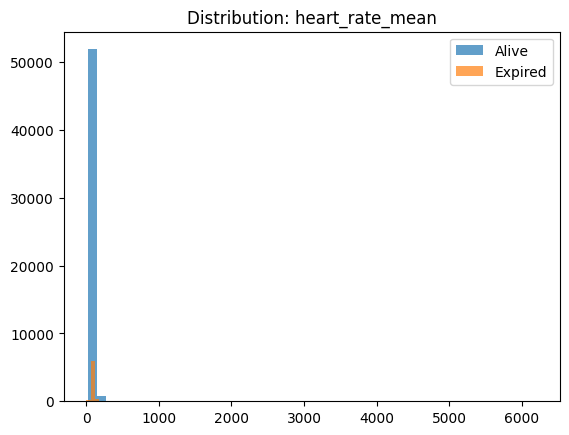

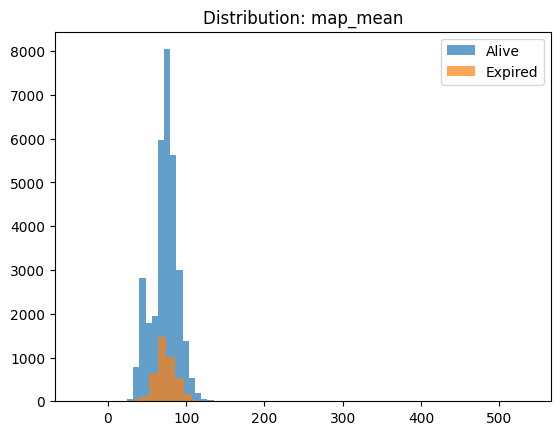

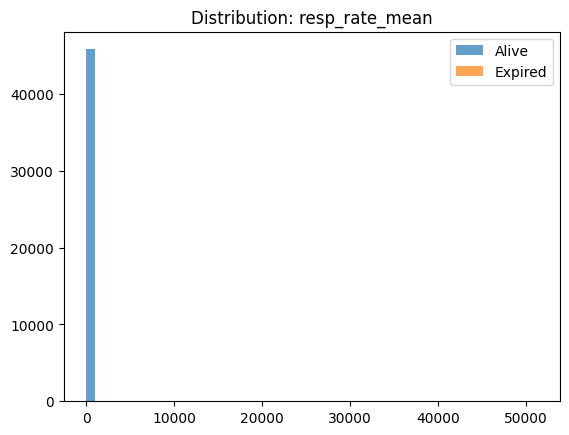

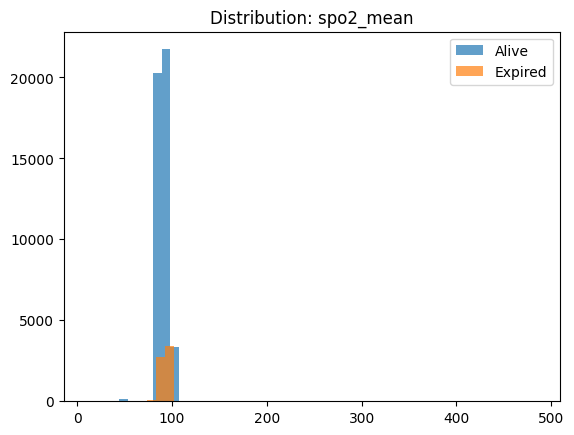

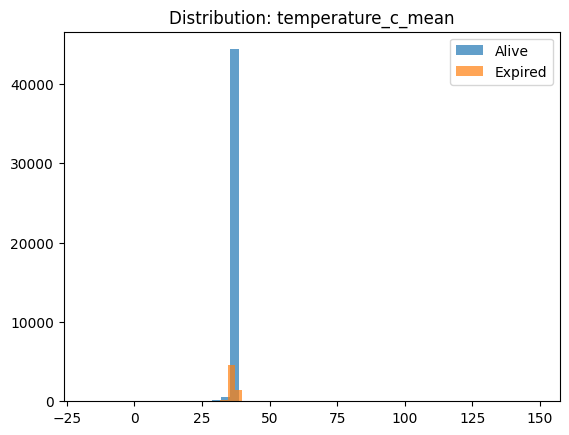

In [14]:
# Distributions of key variables (histograms)
import matplotlib.pyplot as plt

for k in keys[:6]:   # Plot only the first 6 features to avoid generating too many figures
    plt.figure()
    plt.hist(alive[k].dropna().values, bins=50, alpha=0.7, label="Alive")
    plt.hist(dead[k].dropna().values, bins=50, alpha=0.7, label="Expired")
    plt.title(f"Distribution: {k}")
    plt.legend()
    plt.show()

Sampled ICU stays: 2,000
Sampled vitals events (raw subset): 891,374
BEFORE 24h filter:
  Pct in [0,24): 0.2441
  Pct < 0:       0.0062
  Pct >= 24:     0.7497

AFTER 24h filter:
  Kept events: 217,596
  Pct in [0,24): 1.0000 (should be ~1.0)
  Quantiles: {0.01: 0.17166666666666666, 0.05: 1.0219444444444445, 0.5: 10.332222222222223, 0.95: 22.398055555555555, 0.99: 23.67111111111111}


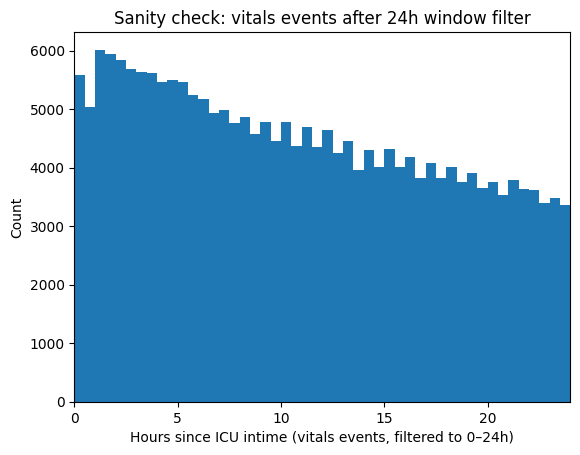

In [17]:
# Time-window sanity check (sampled): verify that the 24h filter keeps events within [0, 24) hours
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

COHORT_PATH = "/content/drive/MyDrive/mimic_outputs/cohort_icustay.parquet"
VITAL_EVENTS = "/content/drive/MyDrive/mimic_data/chartevents_vitals_subset.parquet"

# 1) Load cohort anchors (ICU admission time)
cohort = pd.read_parquet(COHORT_PATH)[["icustay_id", "intime"]].copy()
cohort["intime"] = pd.to_datetime(cohort["intime"], errors="coerce")
cohort = cohort.dropna(subset=["icustay_id", "intime"])

# 2) Sample ICU stays for a lightweight audit (adjustable)
N_SAMPLE = 2000
sample_icustay = cohort["icustay_id"].sample(N_SAMPLE, random_state=42)
c_small = cohort[cohort["icustay_id"].isin(sample_icustay)]

# 3) Load vitals events (subset by ITEMID only; may include all ICU-stay times)
ve = pd.read_parquet(VITAL_EVENTS)
ve["charttime"] = pd.to_datetime(ve["charttime"], errors="coerce")
ve = ve.dropna(subset=["icustay_id", "charttime"])
ve = ve[ve["icustay_id"].isin(sample_icustay)]

# 4) Join ICU intime and compute delta (hours)
ve = ve.merge(c_small, on="icustay_id", how="left")
delta_h = (ve["charttime"] - ve["intime"]).dt.total_seconds() / 3600.0
delta_h = delta_h.dropna()

# 5) BEFORE filtering: show where raw events lie relative to ICU admission
pct_in_0_24_raw = ((delta_h >= 0) & (delta_h < 24)).mean()
pct_lt0_raw = (delta_h < 0).mean()
pct_ge24_raw = (delta_h >= 24).mean()

print(f"Sampled ICU stays: {N_SAMPLE:,}")
print(f"Sampled vitals events (raw subset): {len(delta_h):,}")
print("BEFORE 24h filter:")
print(f"  Pct in [0,24): {pct_in_0_24_raw:.4f}")
print(f"  Pct < 0:       {pct_lt0_raw:.4f}")
print(f"  Pct >= 24:     {pct_ge24_raw:.4f}")

# 6) APPLY the actual 24h window filter and verify the kept events are within [0,24)
ve_24 = ve[(ve["charttime"] >= ve["intime"]) & (ve["charttime"] < ve["intime"] + pd.Timedelta(hours=24))].copy()
delta_h_24 = (ve_24["charttime"] - ve_24["intime"]).dt.total_seconds() / 3600.0
delta_h_24 = delta_h_24.dropna()

pct_in_0_24_after = ((delta_h_24 >= 0) & (delta_h_24 < 24)).mean()

print("\nAFTER 24h filter:")
print(f"  Kept events: {len(delta_h_24):,}")
print(f"  Pct in [0,24): {pct_in_0_24_after:.4f} (should be ~1.0)")
print("  Quantiles:", delta_h_24.quantile([0.01, 0.05, 0.5, 0.95, 0.99]).to_dict())

# 7) Plot only the filtered distribution (0–24h) to avoid confusion
plt.figure()
plt.hist(delta_h_24.values, bins=48)  # ~30-min bins
plt.xlabel("Hours since ICU intime (vitals events, filtered to 0–24h)")
plt.ylabel("Count")
plt.title("Sanity check: vitals events after 24h window filter")
plt.xlim(0, 24)
plt.show()

The filtered distribution covers the full 24h period (median 10.3h; 95th percentile 22.4h), suggesting the window is not inadvertently truncated.

This sanity check verifies correct temporal alignment to ICU admission and confirms that the 24-hour window filter removes post-24h measurements, preventing future information leakage in early mortality prediction.

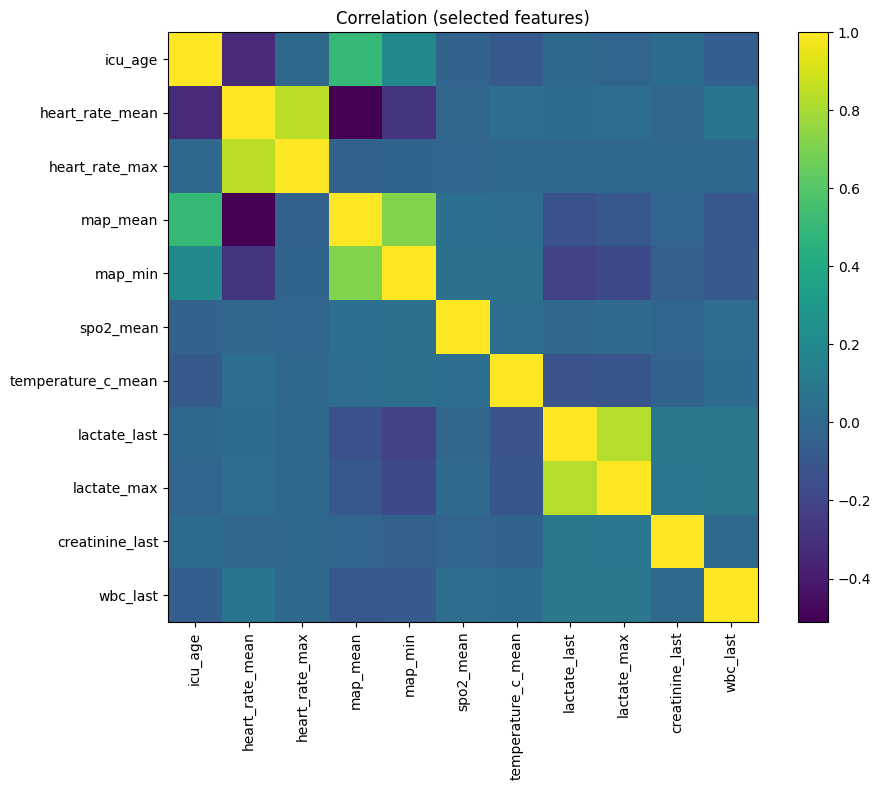

In [18]:
# Correlation heatmap (restricted to a small set of key numeric features)
import matplotlib.pyplot as plt

# Select a subset of clinically important continuous features
corr_cols = [c for c in [
    "icu_age",
    "heart_rate_mean", "heart_rate_max", "map_mean", "map_min", "spo2_mean",
    "temperature_c_mean",
    "lactate_last", "lactate_max",
    "creatinine_last", "bun_last", "wbc_last",
] if c in df.columns]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr.values)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation (selected features)")
plt.colorbar()
plt.tight_layout()
plt.show()

## Key Takeaways

#####**Cohort scale and outcome prevalence are appropriate for ICU early risk modeling.**
*   The cohort is defined at the ICU-stay level (ICUSTAY_ID) with 61,532 ICU stays spanning 46,476 unique patients, and an in-hospital mortality rate of ~10.7%, indicating a moderately imbalanced classification setting where AUROC and especially AUPRC are appropriate primary metrics.



#####**Repeated ICU stays per patient are common → patient-level (group) splitting is mandatory.**
*   The distribution of ICU stays per patient is heavily right-skewed: most patients have a single ICU stay, but a non-trivial long tail exists with multiple stays. This motivates SUBJECT_ID-based group splits to prevent patient leakage across train/test.



#####**The 24-hour window alignment is correct, supporting a valid “early prediction” setup.**
*   The raw vitals event subset spans the entire ICU stay (so only ~24% of events naturally fall within 0–24h). After applying the intended filter [intime, intime + 24h), 100% of retained events fall within 0–24 hours (Pct=1.000), and the filtered distribution covers the full window (median ~10.3h; 95th percentile ~22.4h), confirming correct time anchoring and preventing future information leakage.



#####**Structured feature coverage is strong; missingness reflects clinical ordering behavior rather than ETL errors.**
*   Approximately ~4% of ICU stays have all vitals missing, ~6% have all labs missing, and only ~2% have both vitals and labs entirely missing. The top missing features are largely derived from selectively ordered labs (e.g., bilirubin_total, lactate, INR) and higher-order statistics such as *_std (which require ≥2 measurements), consistent with real-world ICU workflows.


#####**Survivor vs. non-survivor comparisons show clinically plausible separation in early physiology and labs.**
*   Non-survivors are substantially older and exhibit higher early physiologic stress, with clearer separation in labs: lactate (max/last) and creatinine (max/last) are notably higher among expired stays, consistent with hypoperfusion/metabolic stress and renal dysfunction being associated with mortality risk within the first 24 hours.

#####**Correlation structure suggests some redundancy within-variable but complementary information across systems.**
*   As expected, different aggregations of the same signal are strongly correlated (e.g., heart_rate_mean vs heart_rate_max, map_mean vs map_min, lactate_last vs lactate_max). In contrast, cross-domain correlations (vitals vs. labs) are generally weaker, supporting the value of combining vitals and labs for a more complete early risk feature set.
